In [ ]:
!unzip cats_dogs_dataset.zip

Archive:  cats_dogs_dataset.zip
   creating: cats_dogs_dataset/
   creating: cats_dogs_dataset/test/
   creating: cats_dogs_dataset/test/cats/
   creating: cats_dogs_dataset/test/dogs/
   creating: cats_dogs_dataset/train/
   creating: cats_dogs_dataset/train/cats/
  inflating: cats_dogs_dataset/train/cats/809.jpg  
  inflating: cats_dogs_dataset/train/cats/81.jpg  
  inflating: cats_dogs_dataset/train/cats/810.jpg  
  inflating: cats_dogs_dataset/train/cats/811.jpg  
  inflating: cats_dogs_dataset/train/cats/812.jpg  
  inflating: cats_dogs_dataset/train/cats/813.jpg  
  inflating: cats_dogs_dataset/train/cats/814.jpg  
  inflating: cats_dogs_dataset/train/cats/815.jpg  
  inflating: cats_dogs_dataset/train/cats/82.jpg  
  inflating: cats_dogs_dataset/train/cats/83.jpg  
  inflating: cats_dogs_dataset/train/cats/8387.jpg  
  inflating: cats_dogs_dataset/train/cats/8388.jpg  
  inflating: cats_dogs_dataset/train/cats/8389.jpg  
  inflating: cats_dogs_dataset/train/cats/839.jpg  
  infl

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Trainable weights before freezing: 30
Trainable weights after freezing: 4
Found 3598 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Epoch 1/30
 33/100 ━━━━━━━━━━━━━━━━━━━━ 16s 254ms/step - accuracy: 0.5642 - loss: 0.6796

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 356ms/step - accuracy: 0.7008 - loss: 0.5841 - val_accuracy: 0.8400 - val_loss: 0.4171
Epoch 2/30
  1/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.7812 - loss: 0.5046

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.7861 - loss: 0.5035 - val_accuracy: 0.8325 - val_loss: 0.4100
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 261ms/step - accuracy: 0.8042 - loss: 0.4567 - val_accuracy: 0.8750 - val_loss: 0.3254
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8173 - loss: 0.4256 - val_accuracy: 0.8725 - val_loss: 0.3327
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 260ms/step - accuracy: 0.8253 - loss: 0.4085 - val_accuracy: 0.8975 - val_loss: 0.2801
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8125 - loss: 0.4053 - val_accuracy: 0.9050 - val_loss: 0.2791
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 260ms/step - accuracy: 0.8281 - loss: 0.3878 - val_accuracy: 0.8850 - val_loss: 0.2834
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8462 - loss: 0.3890 - val_accuracy: 0.9050 - val_loss: 0.2643
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 270ms/step - accuracy: 0.8278 - loss: 0.3798 - val_accurac

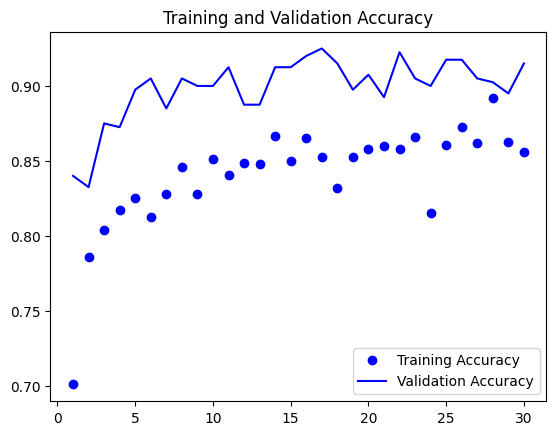

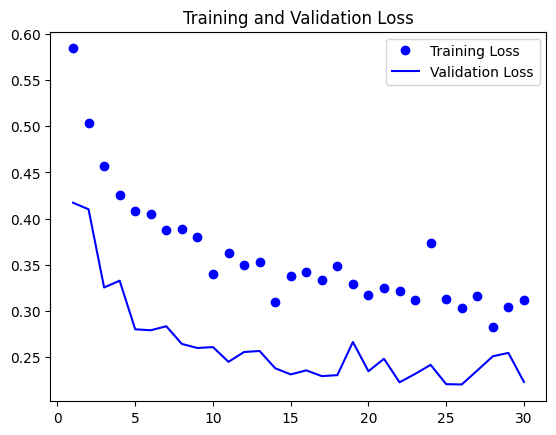

In [ ]:
# This method allows Data Augmentation (GPU recommended)

from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Load pretrained VGG16 convolutional base
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

# Build model
model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

# Freeze convolutional base
print("Trainable weights before freezing:", len(model.trainable_weights))
conv_base.trainable = False
print("Trainable weights after freezing:", len(model.trainable_weights))

# Dataset directories
train_dir="/content/cats_dogs_dataset/train/"
validation_dir="/content/cats_dogs_dataset/validation/"


# Data Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Only rescale validation data
test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

# Validation generator
validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

# Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50
)

# Plot results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, 'bo', label='Training Accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()